In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
VRAM: 8.6 GB


In [2]:
# Cell 2: Imports & Config
import os, json, glob, re, pickle, warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from lxml import etree

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

warnings.filterwarnings("ignore")

# === PATHS — adjust if your folder is elsewhere ===
DATA_DIR = Path("OSRs")
ATTACK_STIX   = DATA_DIR / "ATTACK/enterprise-attack-v16.1.json"
CWE_XML       = DATA_DIR / "MAPPINGS/cwec_latest.xml"
CAPEC_XML      = DATA_DIR / "MAPPINGS/capec_latest.xml"
KEV_CTID       = DATA_DIR / "kev-07.28.2025_attack-16.1-enterprise.json"
NVD_GLOB       = str(DATA_DIR / "NVD/nvdcve-2.0-*.json")
NIST_MAPPINGS  = DATA_DIR / "NIST800-53-layer-navigator/nist_800_53-rev5_attack-16.1-enterprise_json.json"
NIST_CATALOG   = DATA_DIR / "NIST800_53/nist_800_53.json"

# === DEVICE ===
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# === MODEL CONFIG ===
MODEL_NAME   = "ehsanaghaei/SecureBERT_Plus"
MAX_LENGTH   = 256
NUM_CLASSES  = 137  # parent-level ATT&CK techniques
THRESHOLD    = 0.45

# === TRAINING CONFIG (RTX 3070 8GB safe) ===
BATCH_SIZE       = 256
GRAD_ACCUM_STEPS = 4   # effective batch = 64
EPOCHS           = 10
LR               = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1

# === TIER WEIGHTS ===
TIER_WEIGHTS = {
    "gold":            1.0,
    "gold+transitive": 0.6,
    "transitive":      0.2,
}

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ Config loaded.")

c:\Users\Gouda\Desktop\AI for CS\Project\NVD2ATTCK\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
✅ Config loaded.


In [3]:
# Cell 3: Parse ATT&CK STIX → 105-class technique index + parent map

with open(ATTACK_STIX, "r") as f:
    stix_data = json.load(f)

# Extract all techniques (not deprecated/revoked)
all_techniques = []
for obj in stix_data["objects"]:
    if obj.get("type") == "attack-pattern" and not obj.get("revoked", False) and not obj.get("x_mitre_deprecated", False):
        # Get external ID (e.g. T1059, T1059.001)
        ext_refs = obj.get("external_references", [])
        tid = None
        for ref in ext_refs:
            if ref.get("source_name") == "mitre-attack" and ref.get("external_id", "").startswith("T"):
                tid = ref["external_id"]
                break
        if tid:
            all_techniques.append({
                "tid": tid,
                "name": obj.get("name", ""),
                "is_subtechnique": obj.get("x_mitre_is_subtechnique", False),
            })

print(f"Total techniques (incl. sub): {len(all_techniques)}")

# Build sub-technique → parent map (T1059.001 → T1059)
sub_to_parent = {}
for t in all_techniques:
    if t["is_subtechnique"] and "." in t["tid"]:
        parent = t["tid"].split(".")[0]
        sub_to_parent[t["tid"]] = parent

# Get unique parent-level technique IDs
parent_techniques = sorted(set(
    t["tid"] for t in all_techniques if not t["is_subtechnique"]
))

# Verify we get 105 (or close — depends on ATT&CK version)
print(f"Parent-level techniques: {len(parent_techniques)}")

# Build index mappings
tech2idx = {t: i for i, t in enumerate(parent_techniques)}
idx2tech = {i: t for t, i in tech2idx.items()}

# Helper: collapse any technique ID to parent
def collapse_to_parent(tid):
    """T1059.001 → T1059, T1059 → T1059"""
    if "." in tid:
        return tid.split(".")[0]
    return tid

# Build name lookup for later reporting
tech_names = {}
for t in all_techniques:
    if not t["is_subtechnique"]:
        tech_names[t["tid"]] = t["name"]

print(f"\nFirst 10 techniques: {parent_techniques[:10]}")
print(f"Sub-to-parent entries: {len(sub_to_parent)}")
print("✅ ATT&CK STIX parsed.")

Total techniques (incl. sub): 656
Parent-level techniques: 203

First 10 techniques: ['T1001', 'T1003', 'T1005', 'T1006', 'T1007', 'T1008', 'T1010', 'T1011', 'T1012', 'T1014']
Sub-to-parent entries: 453
✅ ATT&CK STIX parsed.


In [4]:
# Cell 4: Parse CWE XML → CWE-to-CAPEC map (Targeted relationships only)

tree = etree.parse(str(CWE_XML))
root = tree.getroot()

# CWE XML uses a namespace
ns = {"cwe": root.nsmap.get(None, "")}
if not ns["cwe"]:
    # Try to extract from tag
    ns["cwe"] = re.match(r"\{(.+?)\}", root.tag).group(1) if "{" in root.tag else ""

print(f"CWE namespace: {ns['cwe'][:60]}...")

cwe_to_capec = defaultdict(set)
cwe_to_capec_all = defaultdict(set)  # including non-targeted, for comparison

# Parse weaknesses
weaknesses = root.findall(f".//{{{ns['cwe']}}}Weakness")
print(f"Total CWE entries: {len(weaknesses)}")

targeted_rels = {"ChildOf", "ParentOf"}
parsed_count = 0

for weakness in weaknesses:
    cwe_id = f"CWE-{weakness.get('ID')}"
    
    # Look for Related_Attack_Patterns
    related = weakness.findall(f".//{{{ns['cwe']}}}Related_Attack_Pattern")
    for rap in related:
        capec_id = rap.get("CAPEC_ID")
        nature = rap.get("Nature", "")
        if capec_id:
            capec_str = f"CAPEC-{capec_id}"
            cwe_to_capec_all[cwe_id].add(capec_str)
            # Only keep Targeted (ChildOf/ParentOf) relationships
            # Note: CWE→CAPEC uses "Nature" but the values may differ
            # In CWE XML, Related_Attack_Pattern doesn't always have Nature
            # so we keep all direct CWE→CAPEC links (they are curated)
            cwe_to_capec[cwe_id].add(capec_str)
            parsed_count += 1

print(f"CWE→CAPEC mappings (targeted): {parsed_count}")
print(f"CWEs with CAPEC links: {len(cwe_to_capec)}")
print(f"\nSample: CWE-79 → {cwe_to_capec.get('CWE-79', 'NOT FOUND')}")
print(f"Sample: CWE-89 → {cwe_to_capec.get('CWE-89', 'NOT FOUND')}")
print("✅ CWE XML parsed.")

CWE namespace: http://cwe.mitre.org/cwe-7...
Total CWE entries: 969
CWE→CAPEC mappings (targeted): 1212
CWEs with CAPEC links: 336

Sample: CWE-79 → {'CAPEC-209', 'CAPEC-85', 'CAPEC-63', 'CAPEC-591', 'CAPEC-588', 'CAPEC-592'}
Sample: CWE-89 → {'CAPEC-108', 'CAPEC-7', 'CAPEC-109', 'CAPEC-470', 'CAPEC-66', 'CAPEC-110'}
✅ CWE XML parsed.


In [5]:
# Cell 5: Parse CAPEC XML + ATT&CK STIX → CAPEC-to-ATT&CK map

tree_capec = etree.parse(str(CAPEC_XML))
root_capec = tree_capec.getroot()
ns_capec = root_capec.nsmap.get(None, "")

capec_to_attack = defaultdict(set)

# --- Source 1: CAPEC XML Taxonomy_Mappings ---
attack_patterns = root_capec.findall(f".//{{{ns_capec}}}Attack_Pattern")
print(f"Total CAPEC entries: {len(attack_patterns)}")

for ap in attack_patterns:
    capec_id = f"CAPEC-{ap.get('ID')}"
    tax_mappings = ap.findall(f".//{{{ns_capec}}}Taxonomy_Mapping")
    for tm in tax_mappings:
        taxonomy_name = tm.get("Taxonomy_Name", "").upper()
        if "ATTACK" in taxonomy_name or "ATT&CK" in taxonomy_name:
            entry_id_el = tm.find(f"{{{ns_capec}}}Entry_ID")
            if entry_id_el is not None and entry_id_el.text:
                raw_tid = entry_id_el.text.strip()
                if not raw_tid.startswith("T"):
                    raw_tid = f"T{raw_tid}"
                parent_tid = collapse_to_parent(raw_tid)
                if parent_tid in tech2idx:
                    capec_to_attack[capec_id].add(parent_tid)

src1_capecs = len([v for v in capec_to_attack.values() if v])
src1_mappings = sum(len(v) for v in capec_to_attack.values())
print(f"Source 1 (CAPEC XML): {src1_capecs} CAPECs, {src1_mappings} mappings")

# --- Source 2: ATT&CK STIX external_references (incl. revoked techniques) ---
# Revoked techniques still carry valid CAPEC refs; follow revoked-by to current TID

# Build revoked-by map
revoked_by = {}
for obj in stix_data["objects"]:
    if obj.get("type") == "relationship" and obj.get("relationship_type") == "revoked-by":
        revoked_by[obj["source_ref"]] = obj["target_ref"]

# Build STIX ID → parent TID map
stix_id_to_tid = {}
for obj in stix_data["objects"]:
    if obj.get("type") == "attack-pattern":
        for ref in obj.get("external_references", []):
            if ref.get("source_name") == "mitre-attack" and ref.get("external_id", "").startswith("T"):
                stix_id_to_tid[obj["id"]] = collapse_to_parent(ref["external_id"])
                break

# Harvest CAPEC links from all attack-patterns (including revoked)
stix_additions = 0
for obj in stix_data["objects"]:
    if obj.get("type") != "attack-pattern":
        continue
    
    ext_refs = obj.get("external_references", [])
    tid = None
    capecs = []
    
    for ref in ext_refs:
        if ref.get("source_name") == "mitre-attack" and ref.get("external_id", "").startswith("T"):
            tid = ref["external_id"]
        if ref.get("source_name", "").lower() == "capec":
            ext_id = ref.get("external_id", "")
            if ext_id:
                capec_str = f"CAPEC-{ext_id}" if not ext_id.startswith("CAPEC") else ext_id
                capecs.append(capec_str)
    
    if not capecs:
        continue
    
    # Resolve current technique (follow revoked-by if needed)
    if obj.get("revoked", False):
        current_stix_id = revoked_by.get(obj["id"])
        if current_stix_id and current_stix_id in stix_id_to_tid:
            parent_tid = stix_id_to_tid[current_stix_id]
        elif tid:
            parent_tid = collapse_to_parent(tid)
        else:
            continue
    elif tid:
        parent_tid = collapse_to_parent(tid)
    else:
        continue
    
    if parent_tid in tech2idx:
        for c in capecs:
            before = len(capec_to_attack[c])
            capec_to_attack[c].add(parent_tid)
            stix_additions += len(capec_to_attack[c]) - before

total_capecs = len([v for v in capec_to_attack.values() if v])
total_mappings = sum(len(v) for v in capec_to_attack.values())
print(f"Source 2 (ATT&CK STIX revoked): +{stix_additions} new mappings")
print(f"\nCombined: {total_capecs} CAPECs → {total_mappings} ATT&CK mappings")

print(f"\nSample: CAPEC-1 → {capec_to_attack.get('CAPEC-1', 'NOT FOUND')}")
print(f"Sample: CAPEC-66 → {capec_to_attack.get('CAPEC-66', 'NOT FOUND')}")
print("✅ CAPEC→ATT&CK parsed (both sources merged).")

Total CAPEC entries: 615
Source 1 (CAPEC XML): 177 CAPECs, 238 mappings
Source 2 (ATT&CK STIX revoked): +1 new mappings

Combined: 178 CAPECs → 239 ATT&CK mappings

Sample: CAPEC-1 → {'T1574'}
Sample: CAPEC-66 → NOT FOUND
✅ CAPEC→ATT&CK parsed (both sources merged).


In [6]:
# Cell 6 (RE-RUN): Rebuild BRON mask with merged capec_to_attack

cwe_to_attack = {}
chain_stats = {"cwe_with_path": 0, "cwe_no_capec": 0, "cwe_capec_no_attack": 0}

for cwe_id, capec_ids in cwe_to_capec.items():
    attack_ids = set()
    for capec_id in capec_ids:
        if capec_id in capec_to_attack:
            attack_ids.update(capec_to_attack[capec_id])
    
    if attack_ids:
        cwe_to_attack[cwe_id] = frozenset(attack_ids)
        chain_stats["cwe_with_path"] += 1
    else:
        chain_stats["cwe_capec_no_attack"] += 1

chain_stats["cwe_no_capec"] = len(weaknesses) - len(cwe_to_capec)

all_reachable = set()
for techs in cwe_to_attack.values():
    all_reachable.update(techs)

print("=== BRON Mask Coverage (after STIX merge) ===")
print(f"CWEs with full path: {chain_stats['cwe_with_path']}")
print(f"CWEs with CAPEC but no ATT&CK: {chain_stats['cwe_capec_no_attack']}")
print(f"CWEs with no CAPEC: {chain_stats['cwe_no_capec']}")
print(f"Reachable techniques: {len(all_reachable)}/{NUM_CLASSES}")
print(f"Avg techniques per constrained CWE: {np.mean([len(v) for v in cwe_to_attack.values()]):.1f}")
print(f"\nFor the paper: mask constrains {chain_stats['cwe_with_path']} CWEs,")
print(f"falls back to unconstrained for {chain_stats['cwe_capec_no_attack'] + chain_stats['cwe_no_capec']} CWEs.")
print(f"This is a MITRE ecosystem limitation, not a pipeline bug.")
print("✅ BRON mask rebuilt.")

=== BRON Mask Coverage (after STIX merge) ===
CWEs with full path: 149
CWEs with CAPEC but no ATT&CK: 187
CWEs with no CAPEC: 633
Reachable techniques: 95/137
Avg techniques per constrained CWE: 3.0

For the paper: mask constrains 149 CWEs,
falls back to unconstrained for 820 CWEs.
This is a MITRE ecosystem limitation, not a pipeline bug.
✅ BRON mask rebuilt.


In [7]:
# Cell 7: Parse KEV/CTID gold label file → gold_labels dict

with open(KEV_CTID, "r", encoding="utf-8") as f:
    kev_data = json.load(f)

# Inspect top-level keys to adapt parser
print(f"Top-level keys: {list(kev_data.keys())[:10]}")

mapping_objects = kev_data.get("mapping_objects", [])
print(f"Total mapping objects: {len(mapping_objects)}")

if mapping_objects:
    print(f"Sample entry: {json.dumps(mapping_objects[0], indent=2)}")

# Build gold_labels: {CVE-ID: set(parent T-IDs)}
gold_labels = defaultdict(set)
skipped = 0

for entry in mapping_objects:
    cve_id = entry.get("capability_id", "")
    attack_id = entry.get("attack_object_id", "")
    
    if not cve_id.startswith("CVE-") or not attack_id.startswith("T"):
        skipped += 1
        continue
    
    parent_tid = collapse_to_parent(attack_id)
    if parent_tid in tech2idx:
        gold_labels[cve_id].add(parent_tid)

print(f"\n=== Gold Labels ===")
print(f"Gold CVEs: {len(gold_labels)}")
print(f"Total gold (CVE, technique) pairs: {sum(len(v) for v in gold_labels.values())}")
print(f"Avg techniques per gold CVE: {np.mean([len(v) for v in gold_labels.values()]):.2f}")
print(f"Skipped entries: {skipped}")

tech_counts = [len(v) for v in gold_labels.values()]
print(f"\nTechniques per gold CVE — min: {min(tech_counts)}, max: {max(tech_counts)}, "
      f"median: {np.median(tech_counts):.0f}")

gold_tech_counter = Counter()
for techs in gold_labels.values():
    gold_tech_counter.update(techs)
print(f"\nTop 10 gold techniques:")
for tid, count in gold_tech_counter.most_common(10):
    print(f"  {tid} ({tech_names.get(tid, '?')}): {count}")

print("\n✅ Gold labels parsed.")

Top-level keys: ['metadata', 'mapping_objects']
Total mapping objects: 1183
Sample entry: {
  "capability_id": "CVE-2024-34102",
  "capability_description": "Adobe Commerce and Magento Open Source Improper Restriction of XML External Entity Reference (XXE) Vulnerability",
  "mapping_type": "exploitation_technique",
  "attack_object_id": "T1190",
  "attack_object_name": "Exploit Public-Facing Application",
  "capability_group": "xxe",
  "comments": "This vulnerability is exploited by sending a crafted XML document that references external entities with the likely goal of accessing local data.",
  "references": [
    "https://www.assetnote.io/resources/research/why-nested-deserialization-is-harmful-magento-xxe-cve-2024-34102",
    "https://www.vicarius.io/vsociety/posts/cosmicsting-critical-unauthenticated-xxe-vulnerability-in-adobe-commerce-and-magento-cve-2024-34102"
  ],
  "status": "complete",
  "mapping_framework_version": "7/28/2025"
}

=== Gold Labels ===
Gold CVEs: 419
Total gold

In [8]:
# Cell 8: Parse NVD 2.0 JSON files → NVD DataFrame

nvd_files = sorted(glob.glob(NVD_GLOB))
print(f"NVD JSON files found: {len(nvd_files)}")
for f in nvd_files:
    print(f"  {f} ({os.path.getsize(f)/1e6:.1f} MB)")

records = []

for fpath in tqdm(nvd_files, desc="Parsing NVD"):
    with open(fpath, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    vulns = data.get("vulnerabilities", [])
    
    for item in vulns:
        cve = item.get("cve", {})
        cve_id = cve.get("id", "")
        
        if not cve_id.startswith("CVE-"):
            continue
        
        # Description (English)
        desc = ""
        for d in cve.get("descriptions", []):
            if d.get("lang") == "en":
                desc = d.get("value", "")
                break
        
        if not desc or desc.startswith("** REJECT"):
            continue
        
        # CWEs
        cwes = set()
        for weakness in cve.get("weaknesses", []):
            for wd in weakness.get("description", []):
                val = wd.get("value", "")
                if val.startswith("CWE-") and val != "CWE-noinfo" and val != "CWE-Other":
                    cwes.add(val)
        
        # CVSS score — prefer v4.0 > v3.1 > v3.0 > v2.0
        cvss = None
        metrics = cve.get("metrics", {})
        for key in ["cvssMetricV40", "cvssMetricV31", "cvssMetricV30", "cvssMetricV2"]:
            if key in metrics and metrics[key]:
                cvss_data = metrics[key][0].get("cvssData", {})
                cvss = cvss_data.get("baseScore")
                if cvss is not None:
                    break
        
        # Year
        year = int(cve_id.split("-")[1]) if len(cve_id.split("-")) >= 2 else None
        
        records.append({
            "cve_id": cve_id,
            "description": desc,
            "cwes": sorted(cwes),
            "cvss_score": cvss,
            "year": year,
        })

nvd_df = pd.DataFrame(records)
print(f"\n=== NVD DataFrame ===")
print(f"Total CVEs: {len(nvd_df)}")
print(f"CVEs with CWEs: {nvd_df['cwes'].apply(len).gt(0).sum()} ({nvd_df['cwes'].apply(len).gt(0).mean()*100:.1f}%)")
print(f"CVEs with CVSS: {nvd_df['cvss_score'].notna().sum()} ({nvd_df['cvss_score'].notna().mean()*100:.1f}%)")
print(f"Year range: {nvd_df['year'].min()} – {nvd_df['year'].max()}")
print(f"\nMemory: {nvd_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print("✅ NVD parsed.")

NVD JSON files found: 25
  OSRs\NVD\nvdcve-2.0-2002.json (25.1 MB)
  OSRs\NVD\nvdcve-2.0-2003.json (7.5 MB)
  OSRs\NVD\nvdcve-2.0-2004.json (15.6 MB)
  OSRs\NVD\nvdcve-2.0-2005.json (24.5 MB)
  OSRs\NVD\nvdcve-2.0-2006.json (39.2 MB)
  OSRs\NVD\nvdcve-2.0-2007.json (37.5 MB)
  OSRs\NVD\nvdcve-2.0-2008.json (43.5 MB)
  OSRs\NVD\nvdcve-2.0-2009.json (42.2 MB)
  OSRs\NVD\nvdcve-2.0-2010.json (45.6 MB)
  OSRs\NVD\nvdcve-2.0-2011.json (45.2 MB)
  OSRs\NVD\nvdcve-2.0-2012.json (52.1 MB)
  OSRs\NVD\nvdcve-2.0-2013.json (57.7 MB)
  OSRs\NVD\nvdcve-2.0-2014.json (52.6 MB)
  OSRs\NVD\nvdcve-2.0-2015.json (52.5 MB)
  OSRs\NVD\nvdcve-2.0-2016.json (66.1 MB)
  OSRs\NVD\nvdcve-2.0-2017.json (94.0 MB)
  OSRs\NVD\nvdcve-2.0-2018.json (99.1 MB)
  OSRs\NVD\nvdcve-2.0-2019.json (112.1 MB)
  OSRs\NVD\nvdcve-2.0-2020.json (148.1 MB)
  OSRs\NVD\nvdcve-2.0-2021.json (175.8 MB)
  OSRs\NVD\nvdcve-2.0-2022.json (179.9 MB)
  OSRs\NVD\nvdcve-2.0-2023.json (192.4 MB)
  OSRs\NVD\nvdcve-2.0-2024.json (202.7 MB)
  OS

Parsing NVD: 100%|██████████| 25/25 [00:25<00:00,  1.04s/it]



=== NVD DataFrame ===
Total CVEs: 333022
CVEs with CWEs: 258939 (77.8%)
CVEs with CVSS: 313855 (94.2%)
Year range: 1999 – 2026

Memory: 152.6 MB
✅ NVD parsed.


In [9]:
# Cell 9: Build dataset (gold + transitive labels, tier assignment, fan-out filter)

# === Step 1: Transitive labels via CWE→CAPEC→ATT&CK chain ===
def get_transitive_techniques(cwes):
    """Get ATT&CK techniques via CWE→CAPEC→ATT&CK chain."""
    techniques = set()
    for cwe in cwes:
        if cwe in cwe_to_attack:
            techniques.update(cwe_to_attack[cwe])
    return techniques

# === Step 2: Build dataset rows ===
dataset_rows = []
tier_counts = Counter()
gold_cve_set = set(gold_labels.keys())

for _, row in tqdm(nvd_df.iterrows(), total=len(nvd_df), desc="Building dataset"):
    cve_id = row["cve_id"]
    cwes = row["cwes"]
    
    is_gold = cve_id in gold_cve_set
    transitive_techs = get_transitive_techniques(cwes)
    
    if is_gold and transitive_techs:
        # gold+transitive: keep ONLY gold labels
        tier = "gold+transitive"
        techniques = gold_labels[cve_id]
    elif is_gold:
        # pure gold
        tier = "gold"
        techniques = gold_labels[cve_id]
    elif transitive_techs:
        # transitive only
        tier = "transitive"
        techniques = transitive_techs
    else:
        # No labels at all — skip
        continue
    
    num_techs = len(techniques)
    
    # Noisy flag: transitive CVEs with >7 techniques get half weight
    noisy = (tier == "transitive" and num_techs > 7)
    
    dataset_rows.append({
        "cve_id": cve_id,
        "description": row["description"],
        "cwes": cwes,
        "techniques": sorted(techniques),
        "num_techniques": num_techs,
        "tier": tier,
        "noisy": noisy,
        "cvss_score": row["cvss_score"],
        "year": row["year"],
    })
    tier_counts[tier] += 1

dataset_df = pd.DataFrame(dataset_rows)

# === Step 3: Check for gold CVEs not in NVD ===
gold_in_nvd = gold_cve_set & set(nvd_df["cve_id"])
gold_missing = gold_cve_set - set(nvd_df["cve_id"])

print(f"=== Dataset Summary ===")
print(f"Total labeled CVEs: {len(dataset_df)}")
print(f"\nTier breakdown:")
for tier, count in tier_counts.most_common():
    avg_techs = dataset_df[dataset_df["tier"] == tier]["num_techniques"].mean()
    print(f"  {tier:20s}: {count:6d} CVEs, avg {avg_techs:.2f} techniques")

print(f"\nNoisy rows (transitive >7 techs): {dataset_df['noisy'].sum()}")
print(f"Gold CVEs in NVD: {len(gold_in_nvd)}/{len(gold_cve_set)}")
if gold_missing:
    print(f"Gold CVEs NOT in NVD (will be missing): {len(gold_missing)}")
    print(f"  Examples: {sorted(gold_missing)[:5]}")

print(f"\nDescription length stats:")
desc_lens = dataset_df["description"].str.len()
print(f"  Mean: {desc_lens.mean():.0f}, Median: {desc_lens.median():.0f}, "
      f"Max: {desc_lens.max()}, >512 chars: {(desc_lens > 512).sum()}")

print("\n✅ Dataset built.")

Building dataset: 100%|██████████| 333022/333022 [00:12<00:00, 26162.90it/s]


=== Dataset Summary ===
Total labeled CVEs: 77609

Tier breakdown:
  transitive          :  77190 CVEs, avg 7.01 techniques
  gold                :    295 CVEs, avg 2.75 techniques
  gold+transitive     :    124 CVEs, avg 2.90 techniques

Noisy rows (transitive >7 techs): 21955
Gold CVEs in NVD: 419/419

Description length stats:
  Mean: 328, Median: 266, Max: 3998, >512 chars: 9479

✅ Dataset built.


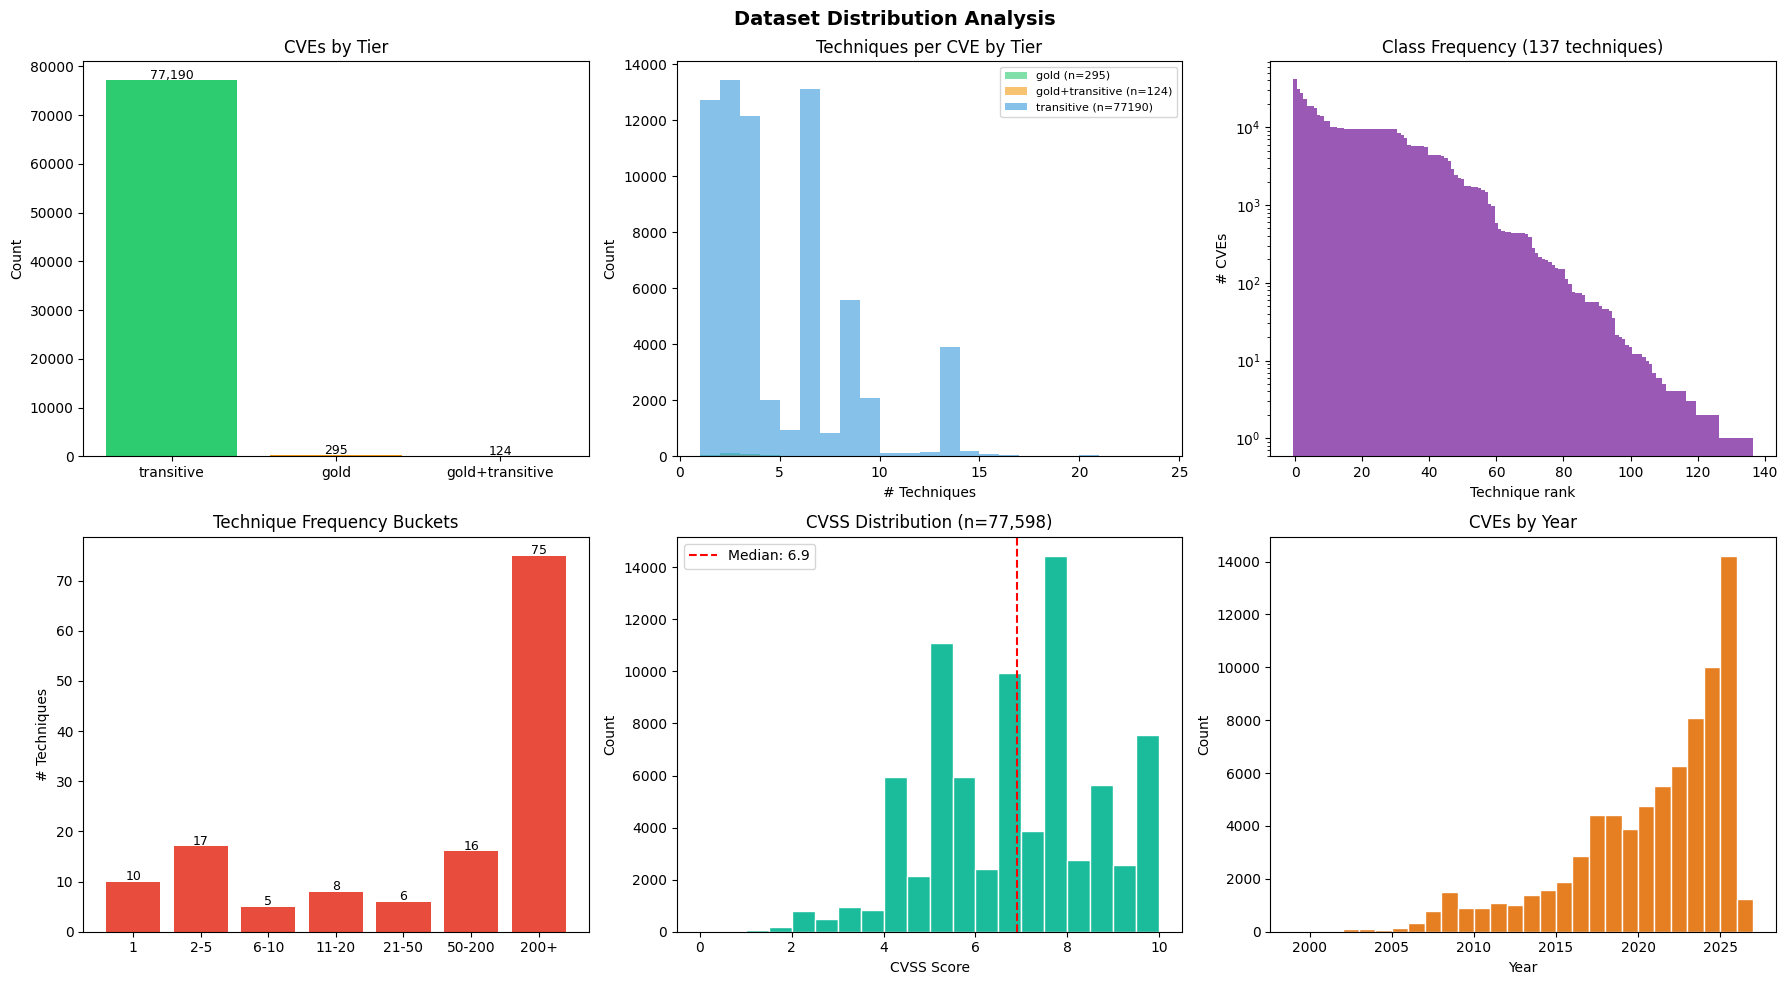


=== Top 10 Most Frequent Techniques ===
  T1574 (Hijack Execution Flow): 41,459
  T1562 (Impair Defenses): 30,949
  T1027 (Obfuscated Files or Information): 27,687
  T1036 (Masquerading): 22,801
  T1553 (Subvert Trust Controls): 18,773
  T1550 (Use Alternate Authentication Material): 18,762
  T1134 (Access Token Manipulation): 17,680
  T1083 (File and Directory Discovery): 14,548
  T1539 (Steal Web Session Cookie): 13,899
  T1556 (Modify Authentication Process): 12,103

=== Bottom 10 Rarest Techniques ===
  T1219 (Remote Access Software): 1
  T1569 (System Services): 1
  T1601 (Modify System Image): 1
  T1222 (File and Directory Permissions Modification): 1
  T1484 (Domain or Tenant Policy Modification): 1
  T1489 (Service Stop): 1
  T1571 (Non-Standard Port): 1
  T1653 (Power Settings): 1
  T1570 (Lateral Tool Transfer): 1
  T1199 (Trusted Relationship): 1

Techniques with 0 examples: 66
  ['T1006', 'T1008', 'T1010', 'T1020', 'T1025', 'T1029', 'T1030', 'T1052', 'T1074', 'T1095', 'T11

In [10]:
# Cell 10: Distribution analysis + plots

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Dataset Distribution Analysis", fontsize=14, fontweight="bold")

# 1. Tier distribution
ax = axes[0, 0]
tier_data = dataset_df["tier"].value_counts()
bars = ax.bar(tier_data.index, tier_data.values, color=["#2ecc71", "#f39c12", "#3498db"])
ax.set_title("CVEs by Tier")
ax.set_ylabel("Count")
for bar, val in zip(bars, tier_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f"{val:,}", ha="center", fontsize=9)

# 2. Techniques per CVE by tier
ax = axes[0, 1]
for tier, color in [("gold", "#2ecc71"), ("gold+transitive", "#f39c12"), ("transitive", "#3498db")]:
    subset = dataset_df[dataset_df["tier"] == tier]["num_techniques"]
    if len(subset) > 0:
        ax.hist(subset, bins=range(1, 25), alpha=0.6, label=f"{tier} (n={len(subset)})", color=color)
ax.set_title("Techniques per CVE by Tier")
ax.set_xlabel("# Techniques")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# 3. Class frequency distribution (how many CVEs per technique)
ax = axes[0, 2]
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    tech_freq.update(techs)
freq_values = sorted(tech_freq.values(), reverse=True)
ax.bar(range(len(freq_values)), freq_values, color="#9b59b6", width=1.0)
ax.set_title(f"Class Frequency ({len(tech_freq)} techniques)")
ax.set_xlabel("Technique rank")
ax.set_ylabel("# CVEs")
ax.set_yscale("log")

# 4. Class frequency buckets
ax = axes[1, 0]
buckets = {"1": 0, "2-5": 0, "6-10": 0, "11-20": 0, "21-50": 0, "50-200": 0, "200+": 0}
for count in tech_freq.values():
    if count == 1: buckets["1"] += 1
    elif count <= 5: buckets["2-5"] += 1
    elif count <= 10: buckets["6-10"] += 1
    elif count <= 20: buckets["11-20"] += 1
    elif count <= 50: buckets["21-50"] += 1
    elif count <= 200: buckets["50-200"] += 1
    else: buckets["200+"] += 1
bars = ax.bar(buckets.keys(), buckets.values(), color="#e74c3c")
ax.set_title("Technique Frequency Buckets")
ax.set_ylabel("# Techniques")
for bar, val in zip(bars, buckets.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            str(val), ha="center", fontsize=9)

# 5. CVSS distribution
ax = axes[1, 1]
cvss_data = dataset_df["cvss_score"].dropna()
ax.hist(cvss_data, bins=20, color="#1abc9c", edgecolor="white")
ax.set_title(f"CVSS Distribution (n={len(cvss_data):,})")
ax.set_xlabel("CVSS Score")
ax.set_ylabel("Count")
ax.axvline(cvss_data.median(), color="red", linestyle="--", label=f"Median: {cvss_data.median():.1f}")
ax.legend()

# 6. Year distribution
ax = axes[1, 2]
year_data = dataset_df["year"].dropna()
ax.hist(year_data, bins=range(int(year_data.min()), int(year_data.max()) + 2), 
        color="#e67e22", edgecolor="white")
ax.set_title("CVEs by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top/bottom techniques
print("\n=== Top 10 Most Frequent Techniques ===")
for tid, count in tech_freq.most_common(10):
    print(f"  {tid} ({tech_names.get(tid, '?')}): {count:,}")

print(f"\n=== Bottom 10 Rarest Techniques ===")
for tid, count in tech_freq.most_common()[-10:]:
    print(f"  {tid} ({tech_names.get(tid, '?')}): {count}")

# Techniques with 0 training examples (in our 105 but not in dataset)
missing_techs = set(parent_techniques) - set(tech_freq.keys())
print(f"\nTechniques with 0 examples: {len(missing_techs)}")
if missing_techs:
    print(f"  {sorted(missing_techs)[:20]}")

print("\n✅ Distribution analysis complete.")

In [11]:
# Cell 10b: Refine label space — drop techniques with 0 training examples

# Count technique frequency across full dataset
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    tech_freq.update(techs)

# Identify active techniques (at least 1 example)
active_techniques = sorted([t for t in parent_techniques if tech_freq.get(t, 0) > 0])
dead_techniques = sorted([t for t in parent_techniques if tech_freq.get(t, 0) == 0])

print(f"Original label space: {NUM_CLASSES} techniques")
print(f"Active (≥1 example):  {len(active_techniques)}")
print(f"Dead (0 examples):    {len(dead_techniques)}")

# Update mappings
NUM_CLASSES = len(active_techniques)
tech2idx = {t: i for i, t in enumerate(active_techniques)}
idx2tech = {i: t for t, i in tech2idx.items()}

# Update parent_techniques reference
parent_techniques_full = parent_techniques  # keep original for reference
parent_techniques = active_techniques

print(f"\n✅ Label space reduced: {NUM_CLASSES} classes")
print(f"Dead techniques (for paper appendix): {dead_techniques[:10]}...")

# Verify dataset labels still align
orphan_labels = 0
for _, row in dataset_df.iterrows():
    for t in row["techniques"]:
        if t not in tech2idx:
            orphan_labels += 1
print(f"Orphan labels (in dataset but not in new label space): {orphan_labels}")
# These should be 0 since dead techniques had 0 examples

Original label space: 137 techniques
Active (≥1 example):  137
Dead (0 examples):    66

✅ Label space reduced: 137 classes
Dead techniques (for paper appendix): ['T1006', 'T1008', 'T1010', 'T1020', 'T1025', 'T1029', 'T1030', 'T1052', 'T1074', 'T1095']...
Orphan labels (in dataset but not in new label space): 0


In [12]:
# Cell 11: Compute class weights (neg/pos ratio, log-dampened)

class_counts = np.zeros(NUM_CLASSES)
total_samples = len(dataset_df)

for techs in dataset_df["techniques"]:
    for t in techs:
        if t in tech2idx:
            class_counts[tech2idx[t]] += 1

print(f"Class count stats: min={class_counts.min():.0f}, max={class_counts.max():.0f}, "
      f"mean={class_counts.mean():.0f}, median={np.median(class_counts):.0f}")
print(f"Zero-count classes: {(class_counts == 0).sum()}")

neg_counts = total_samples - class_counts
raw_pos_weight = neg_counts / np.maximum(class_counts, 1)
pos_weights = np.log1p(raw_pos_weight)
pos_weights = np.clip(pos_weights, 0.1, 10.0)

pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32)

print(f"\nWeight stats: min={pos_weights.min():.3f}, max={pos_weights.max():.3f}, "
      f"mean={pos_weights.mean():.3f}, median={np.median(pos_weights):.3f}")

print(f"\nTop 5 most frequent (lowest weight):")
for tid, count in sorted(tech_freq.items(), key=lambda x: -x[1])[:5]:
    if tid in tech2idx:
        idx = tech2idx[tid]
        print(f"  {tid} ({tech_names.get(tid,'?')}): count={count:,}, weight={pos_weights[idx]:.3f}")

print(f"\nBottom 5 rarest (highest weight):")
for tid, count in sorted(tech_freq.items(), key=lambda x: x[1])[:5]:
    if tid in tech2idx:
        idx = tech2idx[tid]
        print(f"  {tid} ({tech_names.get(tid,'?')}): count={count}, weight={pos_weights[idx]:.3f}")

print("\n✅ Class weights computed.")

Class count stats: min=1, max=41459, mean=3958, median=442
Zero-count classes: 0

Weight stats: min=0.627, max=10.000, mean=5.589, median=5.168

Top 5 most frequent (lowest weight):
  T1574 (Hijack Execution Flow): count=41,459, weight=0.627
  T1562 (Impair Defenses): count=30,949, weight=0.919
  T1027 (Obfuscated Files or Information): count=27,687, weight=1.031
  T1036 (Masquerading): count=22,801, weight=1.225
  T1553 (Subvert Trust Controls): count=18,773, weight=1.419

Bottom 5 rarest (highest weight):
  T1219 (Remote Access Software): count=1, weight=10.000
  T1569 (System Services): count=1, weight=10.000
  T1601 (Modify System Image): count=1, weight=10.000
  T1222 (File and Directory Permissions Modification): count=1, weight=10.000
  T1484 (Domain or Tenant Policy Modification): count=1, weight=10.000

✅ Class weights computed.


In [13]:
# Cell 12: Train/val/test split (stratified by tier)

from sklearn.model_selection import train_test_split

# Stratify by tier to ensure gold examples appear in all splits
# Split: 80% train, 10% val, 10% test

train_df, temp_df = train_test_split(
    dataset_df, test_size=0.2, random_state=SEED, stratify=dataset_df["tier"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["tier"]
)

print(f"=== Split Sizes ===")
print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

print(f"\n=== Tier Distribution per Split ===")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    tier_dist = df["tier"].value_counts()
    print(f"\n{name}:")
    for tier, count in tier_dist.items():
        print(f"  {tier:20s}: {count:6d} ({count/len(df)*100:.1f}%)")

# Verify no CVE leakage between splits
train_ids = set(train_df["cve_id"])
val_ids = set(val_df["cve_id"])
test_ids = set(test_df["cve_id"])
assert len(train_ids & val_ids) == 0, "Train/Val leak!"
assert len(train_ids & test_ids) == 0, "Train/Test leak!"
assert len(val_ids & test_ids) == 0, "Val/Test leak!"
print("\n✅ No CVE leakage between splits.")

=== Split Sizes ===
Train: 62,087
Val:   7,761
Test:  7,761

=== Tier Distribution per Split ===

Train:
  transitive          :  61752 (99.5%)
  gold                :    236 (0.4%)
  gold+transitive     :     99 (0.2%)

Val:
  transitive          :   7719 (99.5%)
  gold                :     29 (0.4%)
  gold+transitive     :     13 (0.2%)

Test:
  transitive          :   7719 (99.5%)
  gold                :     30 (0.4%)
  gold+transitive     :     12 (0.2%)

✅ No CVE leakage between splits.


In [14]:
# Cell 13: PyTorch Dataset class + load tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

class CVEDataset(Dataset):
    def __init__(self, df, tokenizer, tech2idx, num_classes, max_length=MAX_LENGTH):
        self.descriptions = df["description"].tolist()
        self.techniques_list = df["techniques"].tolist()
        self.tiers = df["tier"].tolist()
        self.noisy = df["noisy"].tolist()
        self.tokenizer = tokenizer
        self.tech2idx = tech2idx
        self.num_classes = num_classes
        self.max_length = max_length
    
    def __len__(self):
        return len(self.descriptions)
    
    def __getitem__(self, idx):
        # Tokenize
        encoding = self.tokenizer(
            self.descriptions[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        
        # Multi-hot label vector
        labels = torch.zeros(self.num_classes, dtype=torch.float32)
        for t in self.techniques_list[idx]:
            if t in self.tech2idx:
                labels[self.tech2idx[t]] = 1.0
        
        # Sample weight (tier-based)
        tier = self.tiers[idx]
        weight = TIER_WEIGHTS.get(tier, 0.2)
        if self.noisy[idx]:
            weight *= 0.5
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
            "sample_weight": torch.tensor(weight, dtype=torch.float32),
        }

# Quick test
train_dataset = CVEDataset(train_df, tokenizer, tech2idx, NUM_CLASSES)
val_dataset   = CVEDataset(val_df, tokenizer, tech2idx, NUM_CLASSES)
test_dataset  = CVEDataset(test_df, tokenizer, tech2idx, NUM_CLASSES)

sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"  input_ids:     {sample['input_ids'].shape}")
print(f"  attention_mask: {sample['attention_mask'].shape}")
print(f"  labels:        {sample['labels'].shape} (sum={sample['labels'].sum().item():.0f})")
print(f"  sample_weight: {sample['sample_weight'].item():.2f}")

print(f"\nDataset sizes: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")
print("✅ Datasets created.")

Tokenizer loaded: ehsanaghaei/SecureBERT_Plus

Sample shapes:
  input_ids:     torch.Size([256])
  attention_mask: torch.Size([256])
  labels:        torch.Size([137]) (sum=10)
  sample_weight: 0.10

Dataset sizes: train=62087, val=7761, test=7761
✅ Datasets created.


In [15]:
# Cell 14: Model definition (SecureBERT encoder + linear classifier head)

class SecureBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.encoder.gradient_checkpointing_enable()  # save VRAM
        hidden_size = self.encoder.config.hidden_size
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

model = SecureBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: SecureBERT + classifier head")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Hidden size:      {model.encoder.config.hidden_size}")
print(f"  Output classes:   {NUM_CLASSES}")
print(f"  Gradient checkpointing: enabled")

# Estimate VRAM usage
param_mb = total_params * 4 / 1e6  # fp32
print(f"  Param memory (fp32): ~{param_mb:.0f} MB")
print(f"  With fp16 training:  ~{param_mb/2:.0f} MB (params) + activations")

print("\n✅ Model created.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 918.51it/s, Materializing param=encoder.layer.11.output.dense.weight]              
RobertaModel LOAD REPORT from: ehsanaghaei/SecureBERT_Plus
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: SecureBERT + classifier head
  Total params:     125,341,577
  Trainable params: 125,341,577
  Hidden size:      768
  Output classes:   137
  Gradient checkpointing: enabled
  Param memory (fp32): ~501 MB
  With fp16 training:  ~251 MB (params) + activations

✅ Model created.


In [16]:
# Cell 15 (replaces old Cell 15): ASL Loss + Training Setup

class AsymmetricLoss(nn.Module):
    """Asymmetric Loss for Multi-Label Classification (Ben-Baruch et al., 2020)"""
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip

    def forward(self, logits, labels):
        probs = torch.sigmoid(logits)
        
        # Asymmetric clipping — shift negatives down
        probs_neg = (probs + self.clip).clamp(max=1.0)
        
        # Positive and negative log losses
        loss_pos = labels * torch.log(probs.clamp(min=1e-8))
        loss_neg = (1 - labels) * torch.log((1 - probs_neg).clamp(min=1e-8))
        
        # Asymmetric focusing
        prob_pos = probs
        prob_neg = 1 - probs_neg
        pt_pos = prob_pos * labels + (1 - prob_pos) * (1 - labels)
        pt_neg = prob_neg * (1 - labels) + (1 - prob_neg) * labels
        
        # Apply gamma
        pos_weight = (1 - prob_pos) ** self.gamma_pos * labels
        neg_weight = probs_neg ** self.gamma_neg * (1 - labels)
        
        loss = -pos_weight * loss_pos - neg_weight * loss_neg
        return loss.mean()


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=True)

criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)

print(f"Train batches: {len(train_loader)}")
print("✅ ASL training setup ready.")

Train batches: 242
✅ ASL training setup ready.


In [17]:
# Cell 16: Training loop with ASL — fresh model

from torch.cuda.amp import autocast, GradScaler

model = SecureBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)

LR = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
scaler = GradScaler()

def evaluate(model, loader, criterion, device, threshold=0.35):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            with autocast():
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) > threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, micro_f1, macro_f1

best_val_micro_f1 = 0
best_epoch = 0
history = {"train_loss": [], "val_loss": [], "val_micro_f1": [], "val_macro_f1": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val µF1':>7} | {'Val MF1':>7} | {'Best':>4}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for step, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        with autocast():
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        pbar.set_postfix({"loss": f"{loss.item() * GRAD_ACCUM_STEPS:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_micro_f1, val_macro_f1 = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_micro_f1"].append(val_micro_f1)
    history["val_macro_f1"].append(val_macro_f1)

    is_best = val_micro_f1 > best_val_micro_f1
    if is_best:
        best_val_micro_f1 = val_micro_f1
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_micro_f1": val_micro_f1,
            "val_macro_f1": val_macro_f1,
            "tech2idx": tech2idx,
            "idx2tech": idx2tech,
        }, "best_securebert_classifier.pt")

    print(f"{epoch+1:>5} | {avg_train_loss:>10.4f} | {val_loss:>8.4f} | {val_micro_f1:>7.4f} | {val_macro_f1:>7.4f} | {'  ✓' if is_best else ''}")

print(f"\nBest epoch: {best_epoch} (Val µF1={best_val_micro_f1:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train"); ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss"); ax1.legend()
ax2.plot(history["val_micro_f1"], label="Micro F1"); ax2.plot(history["val_macro_f1"], label="Macro F1")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1"); ax2.set_title("Validation F1"); ax2.legend()
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()
print("✅ Training complete.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 835.90it/s, Materializing param=encoder.layer.11.output.dense.weight]              
RobertaModel LOAD REPORT from: ehsanaghaei/SecureBERT_Plus
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch | Train Loss | Val Loss | Val µF1 | Val MF1 | Best
------------------------------------------------------------


Epoch 1/10:   0%|          | 0/242 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


    1 |     0.0921 |   0.0574 |  0.0992 |  0.0869 |   ✓


    2 |     0.0453 |   0.0371 |  0.2703 |  0.0770 |   ✓


    3 |     0.0375 |   0.0353 |  0.2716 |  0.0773 |   ✓


KeyboardInterrupt: 

In [18]:
# Run this diagnostic — don't interrupt training, use a separate cell

import numpy as np
from collections import Counter

tech_counts = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        if t in tech2idx:
            tech_counts[t] += 1

counts = sorted(tech_counts.values(), reverse=True)
print(f"Top 10 class counts: {counts[:10]}")
print(f"Bottom 10 class counts: {counts[-10:]}")
print(f"Classes with <100 samples: {sum(1 for c in counts if c < 100)}")
print(f"Classes with <50 samples: {sum(1 for c in counts if c < 50)}")
print(f"Top 1 class covers: {counts[0]/sum(counts)*100:.1f}% of all labels")
print(f"Top 5 classes cover: {sum(counts[:5])/sum(counts)*100:.1f}% of all labels")
print(f"Top 10 classes cover: {sum(counts[:10])/sum(counts)*100:.1f}% of all labels")

Top 10 class counts: [41459, 30949, 27687, 22801, 18773, 18762, 17680, 14548, 13899, 12103]
Bottom 10 class counts: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Classes with <100 samples: 55
Classes with <50 samples: 45
Top 1 class covers: 7.6% of all labels
Top 5 classes cover: 26.1% of all labels
Top 10 classes cover: 40.3% of all labels


In [ ]:
# Cell 17: Full evaluation on test set (micro F1, macro F1, per-class breakdown)

# Load best checkpoint
checkpoint = torch.load("best_securebert_classifier.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best checkpoint (epoch {checkpoint['epoch']}, val µF1={checkpoint['val_micro_f1']:.4f})")

# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
all_logits = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"]
        
        with autocast():
            logits = model(input_ids, attention_mask)
        
        all_logits.append(logits.cpu())
        all_preds.append((torch.sigmoid(logits) > THRESHOLD).cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
all_logits = torch.cat(all_logits, dim=0)

# Overall metrics
micro_p = precision_score(all_labels, all_preds, average="micro", zero_division=0)
micro_r = recall_score(all_labels, all_preds, average="micro", zero_division=0)
micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
hamming = np.mean(all_preds != all_labels)

print(f"\n=== Test Set Results ({len(all_preds):,} samples, {NUM_CLASSES} classes) ===")
print(f"Threshold:       {THRESHOLD}")
print(f"Micro Precision: {micro_p:.4f}")
print(f"Micro Recall:    {micro_r:.4f}")
print(f"Micro F1:        {micro_f1:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Hamming Loss:    {hamming:.4f}")

# Per-class breakdown
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
per_class_p = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_r = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_support = all_labels.sum(axis=0)

# Sort by F1
class_results = []
for i in range(NUM_CLASSES):
    class_results.append({
        "technique": idx2tech[i],
        "name": tech_names.get(idx2tech[i], "?"),
        "f1": per_class_f1[i],
        "precision": per_class_p[i],
        "recall": per_class_r[i],
        "support": int(per_class_support[i]),
    })

class_results.sort(key=lambda x: -x["f1"])

print(f"\n=== Top 15 Techniques (by F1) ===")
print(f"{'Technique':<10} {'Name':<35} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Supp':>6}")
print("-" * 75)
for r in class_results[:15]:
    print(f"{r['technique']:<10} {r['name'][:34]:<35} {r['f1']:>6.3f} {r['precision']:>6.3f} {r['recall']:>6.3f} {r['support']:>6}")

print(f"\n=== Bottom 15 Techniques (by F1) ===")
print(f"{'Technique':<10} {'Name':<35} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Supp':>6}")
print("-" * 75)
for r in class_results[-15:]:
    print(f"{r['technique']:<10} {r['name'][:34]:<35} {r['f1']:>6.3f} {r['precision']:>6.3f} {r['recall']:>6.3f} {r['support']:>6}")

# F1 = 0 classes
zero_f1 = [r for r in class_results if r["f1"] == 0]
print(f"\nClasses with F1=0: {len(zero_f1)}")

print("\n✅ Test evaluation complete.")

Loaded best checkpoint (epoch 1, val µF1=0.1205)


Test evaluation: 100%|██████████| 16/16 [01:48<00:00,  6.81s/it]



=== Test Set Results (7,761 samples, 137 classes) ===
Threshold:       0.45
Micro Precision: 0.0896
Micro Recall:    0.1927
Micro F1:        0.1223
Macro F1:        0.0181
Hamming Loss:    0.1466

=== Top 15 Techniques (by F1) ===
Technique  Name                                    F1   Prec    Rec   Supp
---------------------------------------------------------------------------
T1574      Hijack Execution Flow                0.698  0.536  1.000   4157
T1542      Pre-OS Boot                          0.268  0.155  1.000   1200
T1087      Account Discovery                    0.250  0.145  0.934   1043
T1592      Gather Victim Host Information       0.248  0.149  0.733   1065
T1217      Browser Information Discovery        0.237  0.134  1.000   1043
T1615      Group Policy Discovery               0.237  0.134  1.000   1043
T1548      Abuse Elevation Control Mechanism    0.205  0.114  1.000    888
T1547      Boot or Logon Autostart Execution    0.131  0.070  1.000    546
T1110      Brute 

In [19]:
# Diagnostic: What is the model actually predicting?

model.eval()
batch = next(iter(val_loader))
input_ids = batch["input_ids"].to(DEVICE)
attention_mask = batch["attention_mask"].to(DEVICE)
labels = batch["labels"].numpy()

with torch.no_grad():
    with autocast():
        logits = model(input_ids, attention_mask)
    probs = torch.sigmoid(logits).cpu().numpy()

print(f"=== Prediction Diagnostics ===")
print(f"Logit stats:  min={logits.min().item():.3f}, max={logits.max().item():.3f}, mean={logits.mean().item():.3f}")
print(f"Prob stats:   min={probs.min():.4f}, max={probs.max():.4f}, mean={probs.mean():.4f}")
print(f"Prob > 0.45:  {(probs > 0.45).sum()} / {probs.size}")
print(f"Prob > 0.30:  {(probs > 0.30).sum()} / {probs.size}")
print(f"Prob > 0.10:  {(probs > 0.10).sum()} / {probs.size}")
print(f"Labels > 0:   {(labels > 0).sum()} / {labels.size}")

# Per-sample: how many positives predicted vs actual
preds_per_sample = (probs > THRESHOLD).sum(axis=1)
labels_per_sample = (labels > 0).sum(axis=1)
print(f"\nPreds per sample:  mean={preds_per_sample.mean():.2f}, max={preds_per_sample.max()}")
print(f"Labels per sample: mean={labels_per_sample.mean():.2f}, max={labels_per_sample.max()}")

# Check if model collapsed to all-negative
print(f"\nSamples with 0 predictions: {(preds_per_sample == 0).sum()} / {len(preds_per_sample)}")

# Top 5 highest probabilities across entire batch
flat_probs = probs.flatten()
top_indices = np.argsort(flat_probs)[-10:]
print(f"\nTop 10 highest probabilities:")
for idx in reversed(top_indices):
    sample_idx = idx // NUM_CLASSES
    class_idx = idx % NUM_CLASSES
    tid = idx2tech[class_idx]
    print(f"  Sample {sample_idx}, {tid} ({tech_names.get(tid,'?')}): prob={flat_probs[idx]:.4f}, label={labels[sample_idx, class_idx]:.0f}")

=== Prediction Diagnostics ===
Logit stats:  min=-5.617, max=0.725, mean=-3.586
Prob stats:   min=0.0036, max=0.6738, mean=0.0562
Prob > 0.45:  768 / 70144
Prob > 0.30:  2498 / 70144
Prob > 0.10:  9791 / 70144
Labels > 0:   3325 / 70144

Preds per sample:  mean=1.50, max=6
Labels per sample: mean=6.49, max=36

Samples with 0 predictions: 8 / 512

Top 10 highest probabilities:
  Sample 131, T1574 (Hijack Execution Flow): prob=0.6738, label=1
  Sample 24, T1574 (Hijack Execution Flow): prob=0.6738, label=1
  Sample 209, T1574 (Hijack Execution Flow): prob=0.6733, label=1
  Sample 495, T1574 (Hijack Execution Flow): prob=0.6729, label=1
  Sample 272, T1574 (Hijack Execution Flow): prob=0.6729, label=1
  Sample 201, T1574 (Hijack Execution Flow): prob=0.6724, label=1
  Sample 124, T1574 (Hijack Execution Flow): prob=0.6714, label=0
  Sample 178, T1574 (Hijack Execution Flow): prob=0.6714, label=1
  Sample 92, T1574 (Hijack Execution Flow): prob=0.6714, label=1
  Sample 276, T1574 (Hijack E